In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
best_cnn_path = "/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/CNN Model/cnn_experiments.pkl"
best_effnet_frozen_path = "/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/EfficientNetB0 Model/effnet_experiments.pkl"
best_effnet_finetune_path = "/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/EfficientNetB0 fine-tuning Model/effnet_finetuning_experiments.pkl"

final_root_dir = "/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/Final Comparison"
os.makedirs(final_root_dir, exist_ok=True)

final_top3_roc_path = os.path.join(final_root_dir, "top3_best_models_roc.png")

In [4]:
with open(best_cnn_path, "rb") as f:
    best_cnn = pickle.load(f)

with open(best_effnet_frozen_path, "rb") as f:
    best_effnet_frozen = pickle.load(f)

with open(best_effnet_finetune_path, "rb") as f:
    best_effnet_finetune = pickle.load(f)

In [6]:
best_cnn_experiment_name = max(best_cnn, key=lambda name: best_cnn[name]['macro_auc'])
best_effnet_frozen_experiment_name = max(best_effnet_frozen, key=lambda name: best_effnet_frozen[name]['macro_auc'])
best_effnet_finetune_experiment_name = max(best_effnet_finetune, key=lambda name: best_effnet_finetune[name]['macro_auc'])

top3_experiments = {
    best_cnn_experiment_name: best_cnn[best_cnn_experiment_name],
    best_effnet_frozen_experiment_name: best_effnet_frozen[best_effnet_frozen_experiment_name],
    best_effnet_finetune_experiment_name: best_effnet_finetune[best_effnet_finetune_experiment_name]
}

In [7]:
def plot_combined_roc(experiments_dict, class_names, save_path=None):
    plt.figure(figsize=(8, 6))

    for exp_name, exp_data in experiments_dict.items():
        roc_data = np.load(exp_data["roc_raw_data"])

        mean_tpr = []
        mean_fpr = np.linspace(0, 1, 200)

        for i in range(len(class_names)):
            fpr = roc_data[f"fpr_{i}"]
            tpr = roc_data[f"tpr_{i}"]

            interp_tpr = np.interp(mean_fpr, fpr, tpr)
            interp_tpr[0] = 0.0
            mean_tpr.append(interp_tpr)

        mean_tpr = np.mean(mean_tpr, axis=0)
        mean_tpr[-1] = 1.0

        plt.plot(
            mean_fpr,
            mean_tpr,
            label=f"{exp_name} (Macro AUC = {exp_data['macro_auc']:.3f})"
        )

    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison of Best Models")
    plt.legend(loc="lower right")
    plt.grid(True)

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()

In [8]:
Class_Names = ["glioma", "meningioma", "pituitary"]

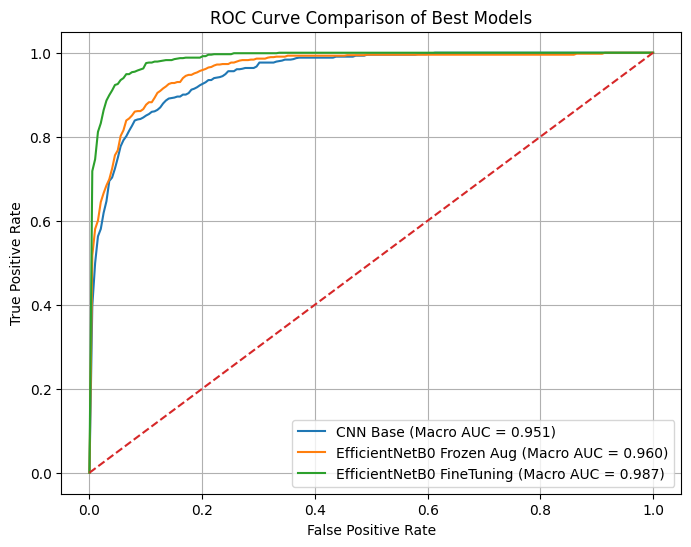

In [9]:
plot_combined_roc(
    top3_experiments,
    Class_Names,
    save_path=final_top3_roc_path
)

In [10]:
for name, data in top3_experiments.items():
    print(f"{name}: Macro AUC = {data['macro_auc']:.4f}")
    print(f"ROC raw data: {data['roc_raw_data']}")
    print("-" * 50)

CNN Base: Macro AUC = 0.9512
ROC raw data: /content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/CNN Model/cnn_base/results/report/cnn_base_roc_raw_data.npz
--------------------------------------------------
EfficientNetB0 Frozen Aug: Macro AUC = 0.9601
ROC raw data: /content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/EfficientNetB0 Model/effnetb0_frozen_aug/results/report/effnetb0_frozen_aug_roc_raw_data.npz
--------------------------------------------------
EfficientNetB0 FineTuning: Macro AUC = 0.9875
ROC raw data: /content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/EfficientNetB0 fine-tuning Model/effnetb0_finetune/results/report/effnetb0_finetune_roc_raw_data.npz
--------------------------------------------------
